# Model Evaluation Report

Walk-forward cross-validation results for all models and baselines.  
Training data: 1991–2019. Walk-forward evaluation: 2005–2024 (n=20 per variety).

**Primary model:** Elastic net with Δ-targets (`src/models/train_ridge.py`)  
**Baselines:** Null · Persistence · Winkler OLS · Full OLS (`src/models/baselines.py`)

Sections:
1. Decision ladder table (RMSE, MAE, R²)
2. Year-by-year prediction vs actual
3. Residual plots by year
4. Save `models/evaluation_metrics.json`

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import ElasticNet

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.models.train_ridge import (
    load_data, get_X, tune,
    NUMERIC_FEATURES, VARIETIES, TARGETS, TRAIN_CUTOFF, WF_START
)
from src.models.baselines import walkforward_baselines

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
COLORS = {
    'Cabernet Sauvignon': '#8B1A1A',
    'Pinot Noir':         '#C04000',
    'Chardonnay':         '#D4AF37',
}
TARGET_LABELS = {'brix': 'Brix', 'tons_crushed': 'Tons Crushed'}
print('Setup complete.')

Setup complete.


## Load data and run walk-forward evaluation

In [2]:
df = load_data()
print(f'Full dataset: {df["year"].min()}–{df["year"].max()} | {len(df)} rows')
print(f'Varieties: {VARIETIES}')
print(f'Targets: {TARGETS}')

Full dataset: 1991–2024 | 102 rows
Varieties: ['Cabernet Sauvignon', 'Pinot Noir', 'Chardonnay']
Targets: ['brix', 'tons_crushed']


In [3]:
# Tune hyperparameters once on data ≤ TRAIN_CUTOFF
print(f'Tuning elastic net on data ≤ {TRAIN_CUTOFF} ...')
best_params = {v: tune(df, v, train_cutoff=TRAIN_CUTOFF) for v in VARIETIES}
for v, p in best_params.items():
    print(f'  {v}: alpha={p["alpha"]}  l1_ratio={p["l1_ratio"]}')

Tuning elastic net on data ≤ 2019 ...
  Cabernet Sauvignon: alpha=1.0  l1_ratio=0.1
  Pinot Noir: alpha=0.01  l1_ratio=0.5
  Chardonnay: alpha=10.0  l1_ratio=0.5


In [4]:
# Walk-forward evaluation: for each year t >= WF_START, train on <t, predict t
# Collect per-year predictions in addition to aggregate metrics
wf_years = sorted(y for y in df['year'].unique() if y >= WF_START)
delta_cols = [f'delta_{t}' for t in TARGETS]

# {variety: {target: [{year, true, pred}]}}
yearly_records: dict = {v: {t: [] for t in TARGETS} for v in VARIETIES}

for variety in VARIETIES:
    params = best_params[variety]
    sub = df[df['variety'] == variety].sort_values('year').reset_index(drop=True)

    for year in wf_years:
        train = sub[sub['year'] < year].dropna(subset=NUMERIC_FEATURES + delta_cols)
        test  = sub[sub['year'] == year].dropna(subset=NUMERIC_FEATURES)
        if len(train) < 10 or len(test) == 0:
            continue

        X_train, scaler = get_X(train, fit=True)
        X_test, _       = get_X(test, scaler=scaler)

        for tgt in TARGETS:
            m = ElasticNet(max_iter=5000, random_state=42, **params)
            m.fit(X_train, train[f'delta_{tgt}'].values)

            pred_abs = test[f'{tgt}_lag1'].values + m.predict(X_test)
            true_abs = test[tgt].values
            for true_v, pred_v in zip(true_abs, pred_abs):
                if not (np.isnan(true_v) or np.isnan(pred_v)):
                    yearly_records[variety][tgt].append({
                        'year': year, 'true': float(true_v), 'pred': float(pred_v)
                    })

print('Walk-forward complete.')
for v in VARIETIES:
    n = len(yearly_records[v]['brix'])
    print(f'  {v}: {n} brix predictions')

Walk-forward complete.
  Cabernet Sauvignon: 20 brix predictions
  Pinot Noir: 20 brix predictions
  Chardonnay: 20 brix predictions


In [5]:
# Compute aggregate metrics for elastic net
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def metrics(records):
    if len(records) < 2:
        return {'rmse': float('nan'), 'mae': float('nan'), 'r2': float('nan'), 'n': len(records)}
    y_true = np.array([r['true'] for r in records])
    y_pred = np.array([r['pred'] for r in records])
    return {
        'rmse': round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        'mae':  round(float(mean_absolute_error(y_true, y_pred)), 4),
        'r2':   round(float(r2_score(y_true, y_pred)), 4),
        'n':    len(records),
    }

ridge_metrics = {
    v: {t: metrics(yearly_records[v][t]) for t in TARGETS}
    for v in VARIETIES
}

print('Elastic net walk-forward metrics:')
for v in VARIETIES:
    for t in TARGETS:
        m = ridge_metrics[v][t]
        print(f'  {v} | {t}: RMSE={m["rmse"]}  MAE={m["mae"]}  R²={m["r2"]}')

Elastic net walk-forward metrics:
  Cabernet Sauvignon | brix: RMSE=0.5892  MAE=0.4675  R²=-0.063
  Cabernet Sauvignon | tons_crushed: RMSE=15638.0654  MAE=12507.6179  R²=-0.4568
  Pinot Noir | brix: RMSE=0.6547  MAE=0.5453  R²=0.3506
  Pinot Noir | tons_crushed: RMSE=2519.5828  MAE=2019.0041  R²=-0.8942
  Chardonnay | brix: RMSE=0.406  MAE=0.3285  R²=0.3164
  Chardonnay | tons_crushed: RMSE=6146.5439  MAE=4843.5782  R²=-0.2782


In [6]:
# Compute walk-forward baselines (same window 2005–2024)
from src.models.baselines import load_data as bl_load_data

print('Computing walk-forward baselines ...')
bl_df = bl_load_data()
baseline_results = walkforward_baselines(bl_df, wf_start=WF_START)
print('Baselines computed.')

Computing walk-forward baselines ...
Baselines computed.


## Part 1 — Decision Ladder Table

Walk-forward RMSE for all models. Lower is better.  
Bold = best in column (lowest RMSE).

Baseline ladder (ascending sophistication):
1. **Null / Historical mean** — predict training-set mean; floor for any useful model
2. **Winkler OLS** — single-feature OLS using Winkler GDD index; industry thermal standard
3. **Full OLS** — OLS on all 11 numeric features; no regularization or nonlinearity
4. **Persistence** — predict this year = last year; captures autocorrelation floor
5. **Elastic net Δ** — this work; predicts Δbrix / Δtons, persistence is implicit zero

In [7]:
MODELS_ORDERED = [
    ('null',           'Null / Hist. Mean'),
    ('winkler_linear', 'Winkler OLS'),
    ('full_ols',       'Full OLS'),
    ('persistence',    'Persistence'),
    ('elastic_net',    'Elastic Net Δ (this work)'),
]

for tgt in TARGETS:
    rows = []
    for key, label in MODELS_ORDERED:
        row = {'Model': label}
        for v in VARIETIES:
            short = v.split()[0]  # 'Cabernet', 'Pinot', 'Chardonnay'
            if key == 'elastic_net':
                m = ridge_metrics[v][tgt]
            else:
                m = baseline_results[key][v][tgt]
            row[short] = m['rmse']
        rows.append(row)

    table = pd.DataFrame(rows).set_index('Model')

    # Bold minimum in each column
    def bold_min(col):
        is_min = col == col.min()
        return ['font-weight: bold' if v else '' for v in is_min]

    fmt = '{:.3f}'
    display_label = TARGET_LABELS[tgt]
    print(f'\n=== {display_label} — Walk-forward RMSE (2005–2024) ===')
    styled = table.style.apply(bold_min).format(fmt)
    display(styled)


=== Brix — Walk-forward RMSE (2005–2024) ===


,Cabernet,Pinot,Chardonnay
Model,,,
Null / Hist. Mean,1.067,0.938,0.505
Winkler OLS,0.955,0.942,0.533
Full OLS,0.847,0.836,0.831
Persistence,0.577,0.442,0.368
Elastic Net Δ (this work),0.589,0.655,0.406



=== Tons Crushed — Walk-forward RMSE (2005–2024) ===


,Cabernet,Pinot,Chardonnay
Model,,,
Null / Hist. Mean,22809.953,1875.739,6516.236
Winkler OLS,22994.846,2198.428,6494.084
Full OLS,18343.683,2538.930,8186.027
Persistence,15666.800,2177.877,6130.458
Elastic Net Δ (this work),15638.065,2519.583,6146.544


## Part 2 — Year-by-Year Prediction vs Actual

Walk-forward predictions overlaid on observed values. Shaded band = ±1 RMSE.

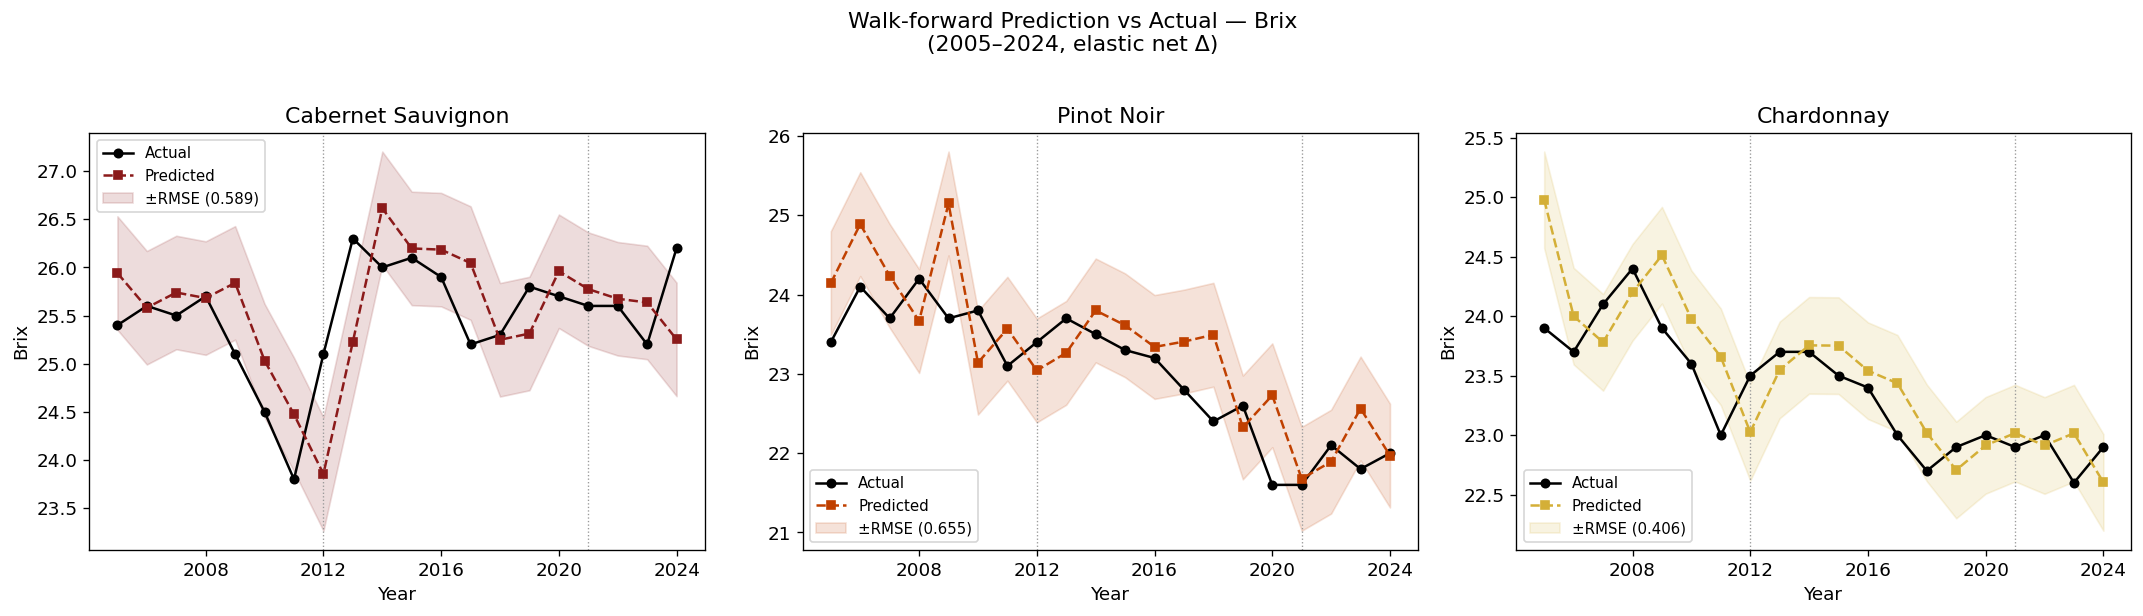

Saved → models/pred_vs_actual_brix.png


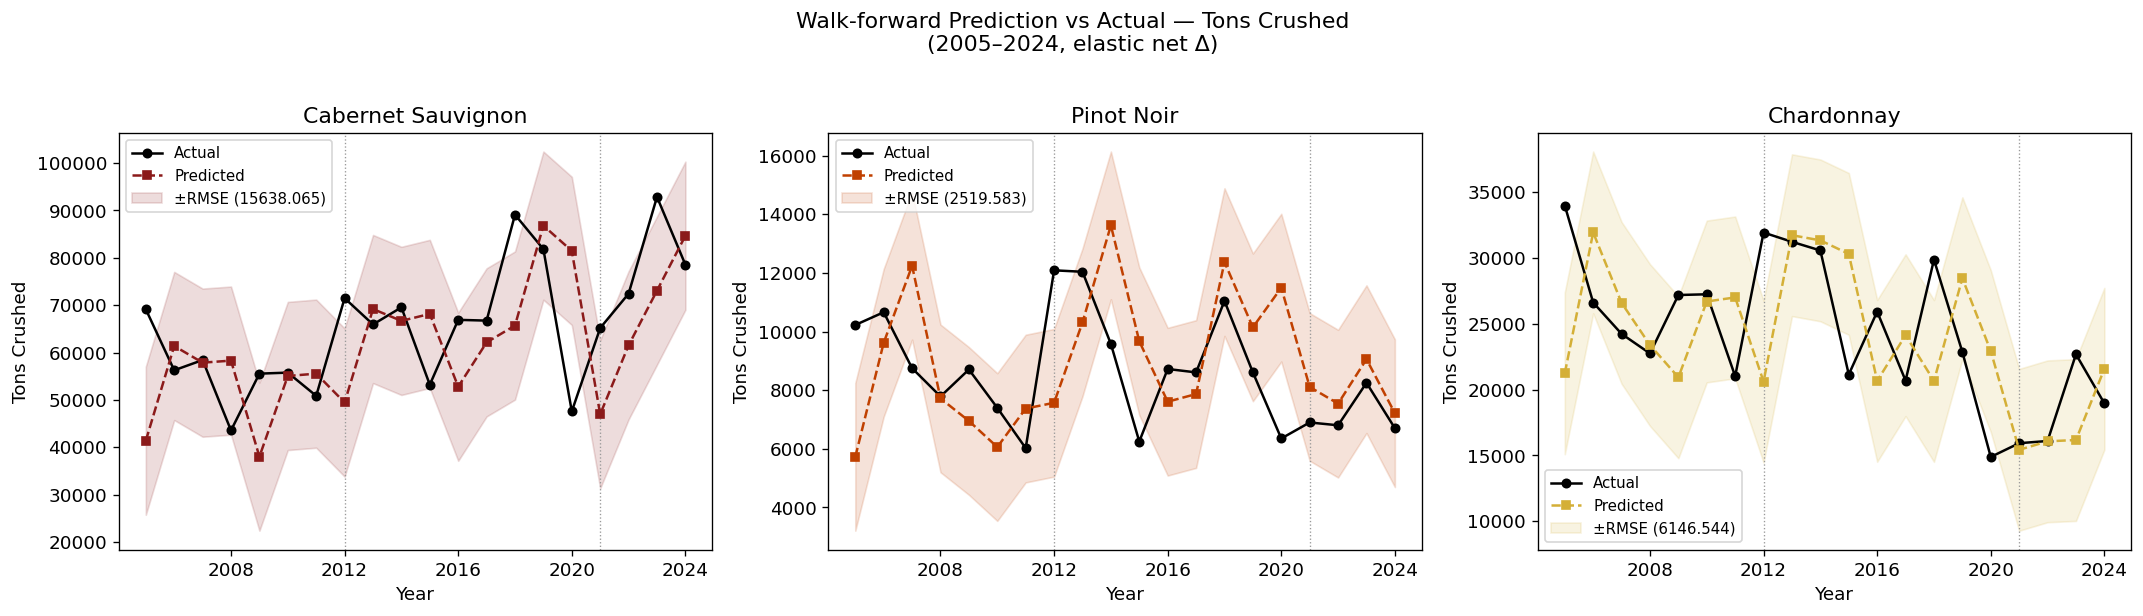

Saved → models/pred_vs_actual_tons_crushed.png


In [8]:
for tgt in TARGETS:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
    fig.suptitle(
        f'Walk-forward Prediction vs Actual — {TARGET_LABELS[tgt]}\n(2005–2024, elastic net Δ)',
        y=1.02,
    )

    for ax, variety in zip(axes, VARIETIES):
        recs = sorted(yearly_records[variety][tgt], key=lambda r: r['year'])
        if not recs:
            ax.set_title(variety)
            continue

        years = [r['year'] for r in recs]
        trues = np.array([r['true'] for r in recs])
        preds = np.array([r['pred'] for r in recs])
        rmse  = ridge_metrics[variety][tgt]['rmse']

        ax.plot(years, trues, 'o-', color='black',       lw=1.5, ms=5, label='Actual',    zorder=3)
        ax.plot(years, preds, 's--', color=COLORS[variety], lw=1.5, ms=5, label='Predicted', zorder=3)
        ax.fill_between(years, preds - rmse, preds + rmse,
                        color=COLORS[variety], alpha=0.15, label=f'±RMSE ({rmse:.3f})')

        # Mark drought years lightly
        for yr in [2012, 2021]:
            if yr in years:
                ax.axvline(yr, color='#999999', lw=0.8, linestyle=':')

        ax.set_title(variety)
        ax.set_xlabel('Year')
        ax.set_ylabel(TARGET_LABELS[tgt])
        ax.legend(fontsize=9)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=6))

    plt.tight_layout()
    out = ROOT / 'models' / f'pred_vs_actual_{tgt}.png'
    plt.savefig(out, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved → models/pred_vs_actual_{tgt}.png')

## Part 3 — Residual Plots by Year

Residual = predicted − actual. Systematic patterns by decade or drought period indicate model bias.

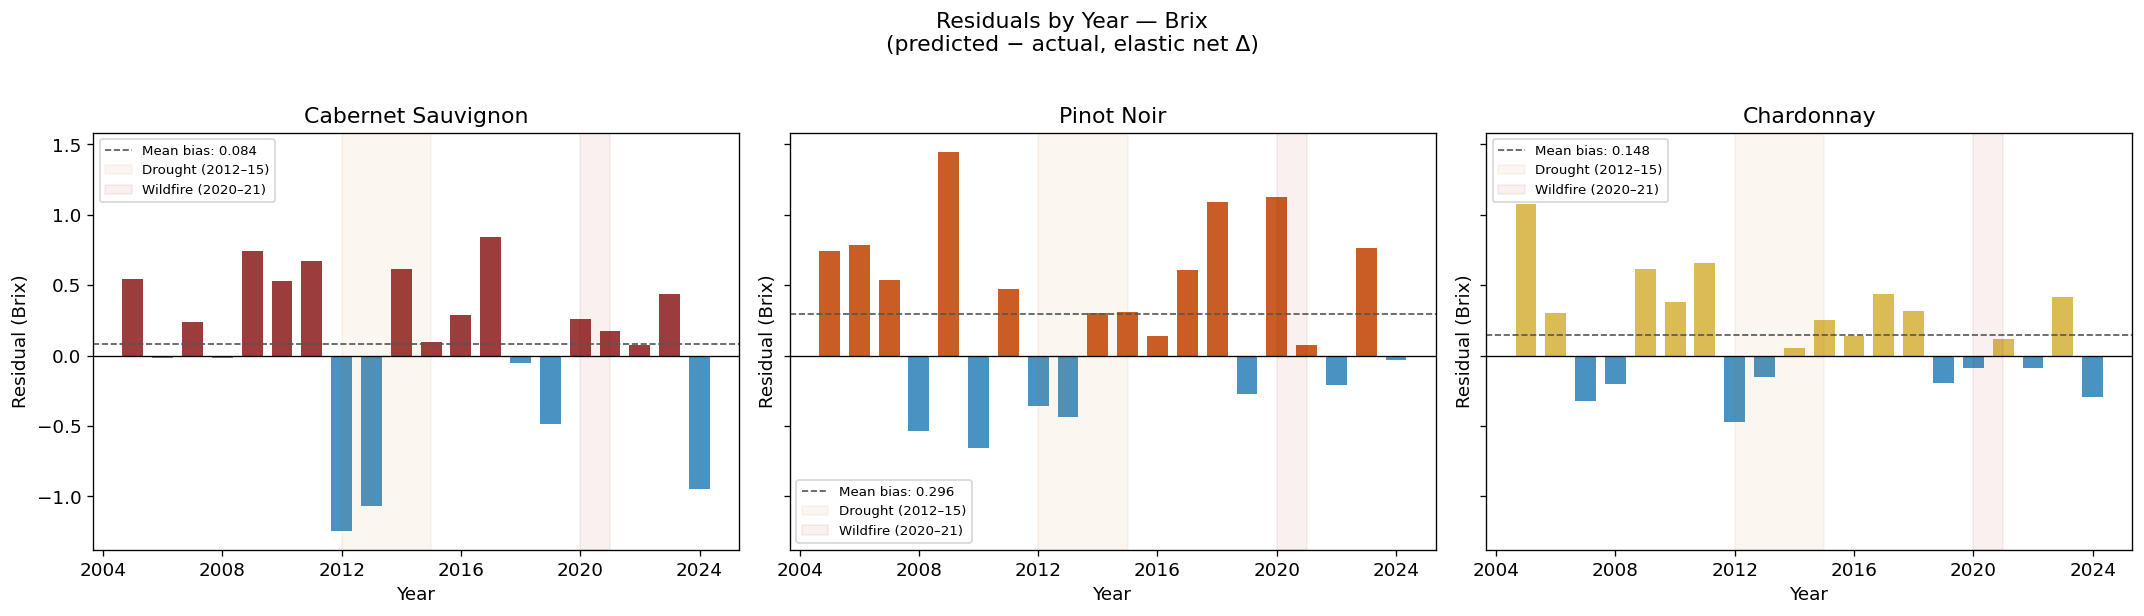

Saved → models/residuals_brix.png


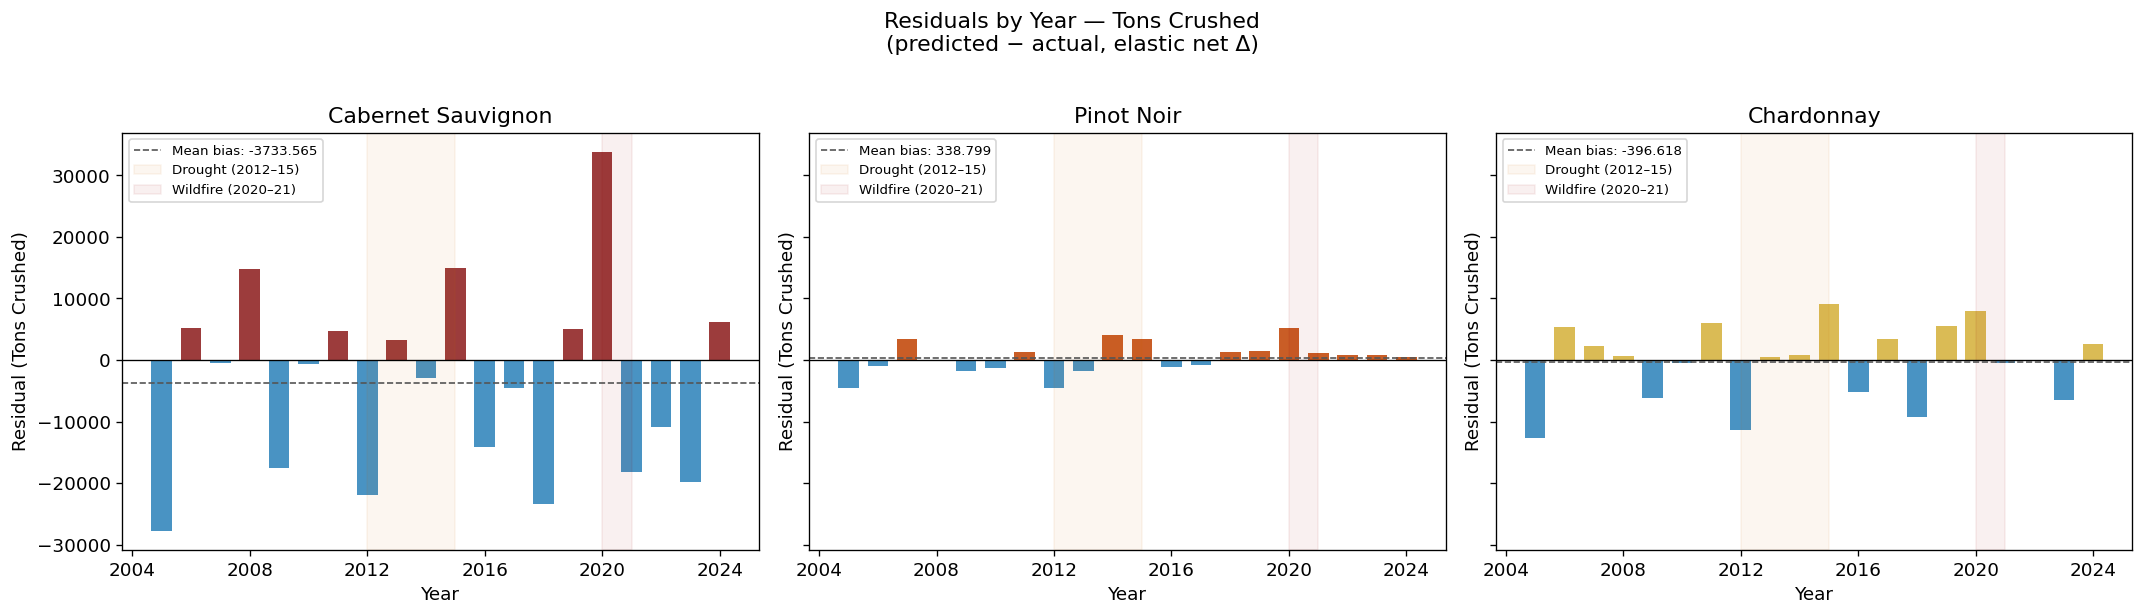

Saved → models/residuals_tons_crushed.png


In [9]:
for tgt in TARGETS:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(
        f'Residuals by Year — {TARGET_LABELS[tgt]}\n(predicted − actual, elastic net Δ)',
        y=1.02,
    )

    for ax, variety in zip(axes, VARIETIES):
        recs = sorted(yearly_records[variety][tgt], key=lambda r: r['year'])
        if not recs:
            ax.set_title(variety)
            continue

        years = np.array([r['year'] for r in recs])
        resid = np.array([r['pred'] - r['true'] for r in recs])

        ax.bar(years, resid, color=[
            COLORS[variety] if r >= 0 else '#2980b9' for r in resid
        ], width=0.7, alpha=0.85)
        ax.axhline(0, color='black', lw=0.8)
        ax.axhline(resid.mean(), color='#555555', lw=1.0, linestyle='--',
                   label=f'Mean bias: {resid.mean():.3f}')

        # Shade drought period
        ax.axvspan(2012, 2015, alpha=0.06, color='#cc6600', label='Drought (2012–15)')
        ax.axvspan(2020, 2021, alpha=0.06, color='#990000', label='Wildfire (2020–21)')

        ax.set_title(variety)
        ax.set_xlabel('Year')
        ax.set_ylabel(f'Residual ({TARGET_LABELS[tgt]})')
        ax.legend(fontsize=8)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=6))

    plt.tight_layout()
    out = ROOT / 'models' / f'residuals_{tgt}.png'
    plt.savefig(out, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved → models/residuals_{tgt}.png')

## Part 4 — Scatter: Predicted vs Actual

Calibration check — points near the diagonal indicate well-calibrated predictions.

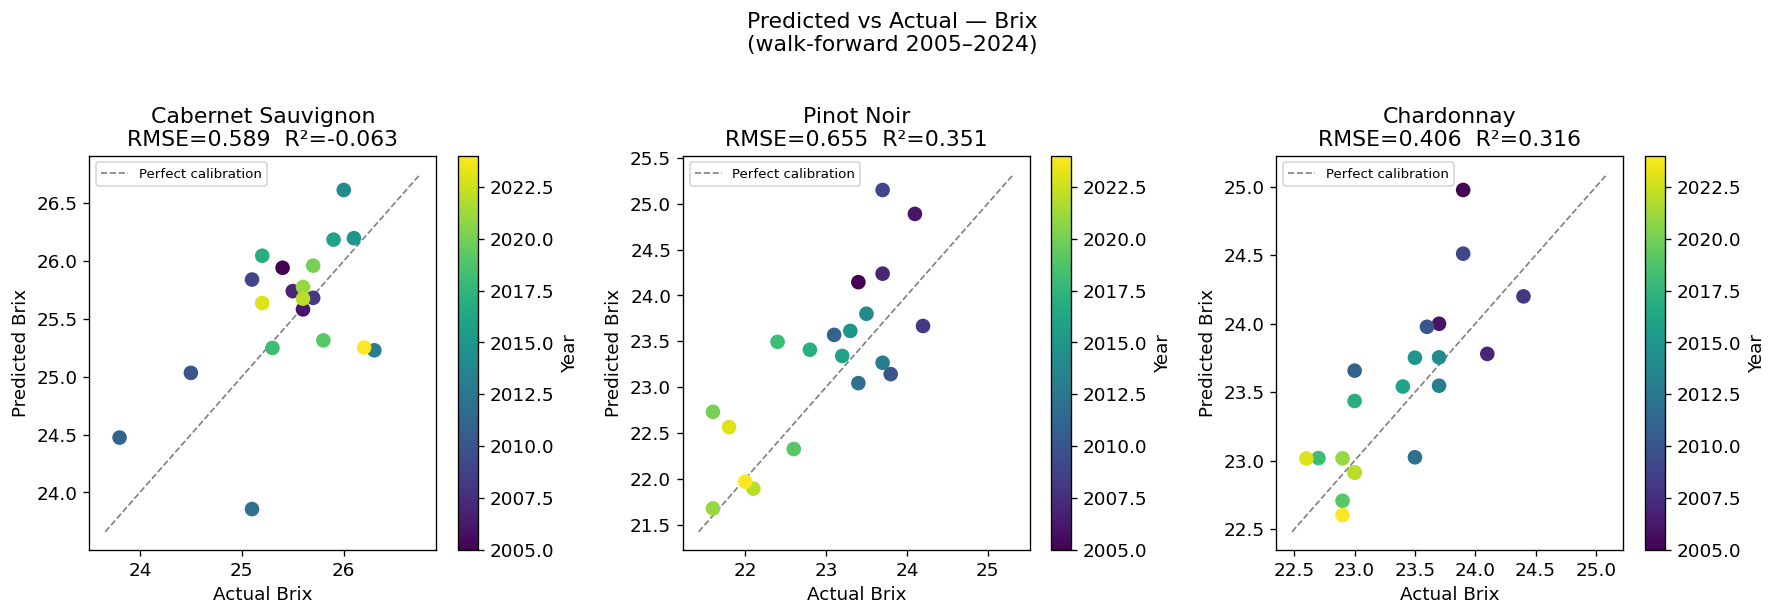

Saved → models/scatter_brix.png


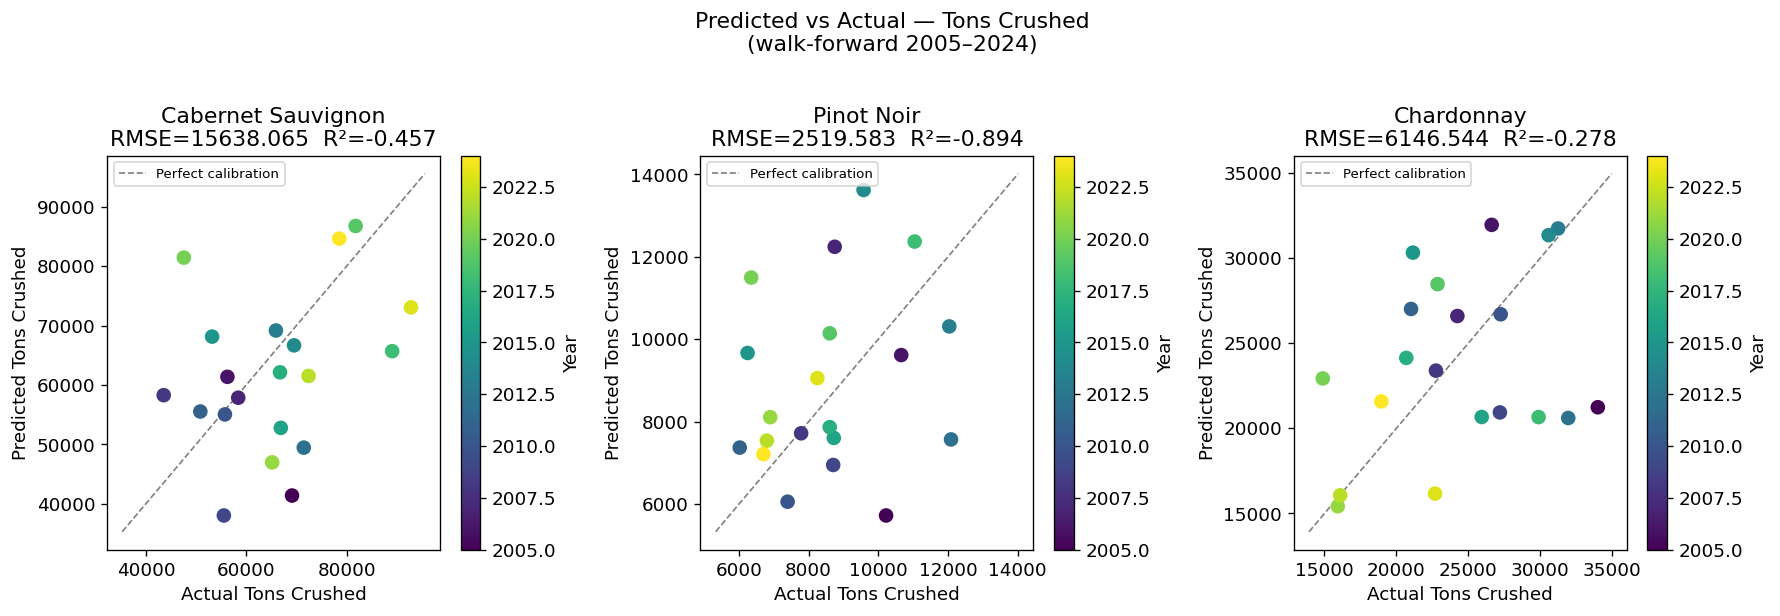

Saved → models/scatter_tons_crushed.png


In [10]:
for tgt in TARGETS:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f'Predicted vs Actual — {TARGET_LABELS[tgt]}\n(walk-forward 2005–2024)',
        y=1.02,
    )

    for ax, variety in zip(axes, VARIETIES):
        recs = yearly_records[variety][tgt]
        if not recs:
            ax.set_title(variety)
            continue

        trues = np.array([r['true'] for r in recs])
        preds = np.array([r['pred'] for r in recs])
        years = [r['year'] for r in recs]

        sc = ax.scatter(trues, preds, c=years, cmap='viridis', s=60, zorder=3)
        plt.colorbar(sc, ax=ax, label='Year')

        lo = min(trues.min(), preds.min())
        hi = max(trues.max(), preds.max())
        pad = (hi - lo) * 0.05
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
                'k--', lw=1, alpha=0.5, label='Perfect calibration')

        m = ridge_metrics[variety][tgt]
        ax.set_title(f'{variety}\nRMSE={m["rmse"]:.3f}  R²={m["r2"]:.3f}')
        ax.set_xlabel(f'Actual {TARGET_LABELS[tgt]}')
        ax.set_ylabel(f'Predicted {TARGET_LABELS[tgt]}')
        ax.legend(fontsize=8)

    plt.tight_layout()
    out = ROOT / 'models' / f'scatter_{tgt}.png'
    plt.savefig(out, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved → models/scatter_{tgt}.png')

## Part 5 — Save evaluation_metrics.json

In [11]:
# Build full metrics payload
evaluation_metrics = {
    'meta': {
        'evaluation_window': f'{WF_START}–{wf_years[-1]}',
        'n_years': len(wf_years),
        'protocol': 'walk-forward CV: train on <t, predict t',
        'primary_model': 'elastic_net_delta',
        'train_cutoff_for_tuning': TRAIN_CUTOFF,
    },
    'elastic_net_delta': ridge_metrics,
}

# Include baselines for completeness
for baseline_key in ['null', 'persistence', 'winkler_linear', 'full_ols']:
    if baseline_key in baseline_results:
        evaluation_metrics[baseline_key] = baseline_results[baseline_key]

out_path = ROOT / 'models' / 'evaluation_metrics.json'
with open(out_path, 'w') as f:
    json.dump(evaluation_metrics, f, indent=2)

print(f'Saved → models/evaluation_metrics.json')
print()

# Summary table
print('=== Final comparison (walk-forward RMSE) ===')
for tgt in TARGETS:
    print(f'\n{tgt.upper()}')
    header = f'  {"Model":<26}  ' + '  '.join(f'{v.split()[0]:>12}' for v in VARIETIES)
    print(header)
    print('  ' + '-'*65)
    for key, label in MODELS_ORDERED:
        row = f'  {label:<26}'
        for v in VARIETIES:
            if key == 'elastic_net':
                rmse = ridge_metrics[v][tgt]['rmse']
            else:
                rmse = baseline_results[key][v][tgt]['rmse']
            row += f'  {rmse:>12.3f}'
        print(row)

Saved → models/evaluation_metrics.json

=== Final comparison (walk-forward RMSE) ===

BRIX
  Model                           Cabernet         Pinot    Chardonnay
  -----------------------------------------------------------------
  Null / Hist. Mean                  1.067         0.938         0.505
  Winkler OLS                        0.955         0.942         0.533
  Full OLS                           0.847         0.836         0.831
  Persistence                        0.577         0.442         0.368
  Elastic Net Δ (this work)          0.589         0.655         0.406

TONS_CRUSHED
  Model                           Cabernet         Pinot    Chardonnay
  -----------------------------------------------------------------
  Null / Hist. Mean              22809.953      1875.739      6516.236
  Winkler OLS                    22994.846      2198.428      6494.084
  Full OLS                       18343.683      2538.930      8186.027
  Persistence                    15666.800      2